In [1]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from tqdm.notebook import tqdm
import seaborn as sns
from collections import Counter

In [2]:
filepath = "data/output_1000_seq3.root"
data = uproot.open(filepath + ":L1BMTFStubSequences").arrays()
df = ak.to_dataframe(data)
df.head()

nL1BMTFStub  L1BMTFStub_hwQual  L1BMTFStub_hwPhi  \
entry subentry                                                     
0     0                   1                  4               674   
1     0                   1                  2              -278   
2     0                   2                  5               674   
      1                   2                  6             -1092   
3     0                   3                  6               861   

                L1BMTFStub_hwPhiB  L1BMTFStub_hwEta  L1BMTFStub_hwQEta  \
entry subentry                                                           
0     0                       282                 0                  0   
1     0                        87                 0                  0   
2     0                       279                32                 32   
      1                       163                16                  0   
3     0                       220                16                  0   

                L1BMTFStub_wheel  L1BMTFStub_sector  L1BMTFStub_station  \
entry subentry                                                            
0     0                       -1                  8                   1   
1     0                        1                  9                   1   
2     0                       -1                  8                   1   
      1                       -1                  9                   2   
3     0                       -1                  2                   1   

                orbitNumber  bunchCrossing  sequenceIndex  
entry subentry                                             
0     0           261881864            986              0  
1     0           261881864            987              0  
2     0           261881864            988              0  
      1           261881864            988              0  
3     0           261881864           1164              1

In [3]:
dfgb = df.groupby("sequenceIndex")

index = 45
print(f"Sequence: {index}")

dfg = dfgb.get_group(index)
for sector, dfsector in dfg.groupby("L1BMTFStub_sector"):
    print(f'\tSector: {sector}, Wheel: {dfsector["L1BMTFStub_wheel"].values}, Station: {dfsector["L1BMTFStub_station"].values}, BX: {dfsector["bunchCrossing"].values}')

Sequence: 45
	Sector: 1, Wheel: [0 0 0], Station: [1 1 2], BX: [2606 2607 2607]
	Sector: 2, Wheel: [-1], Station: [3], BX: [2607]
	Sector: 5, Wheel: [1], Station: [1], BX: [2605]


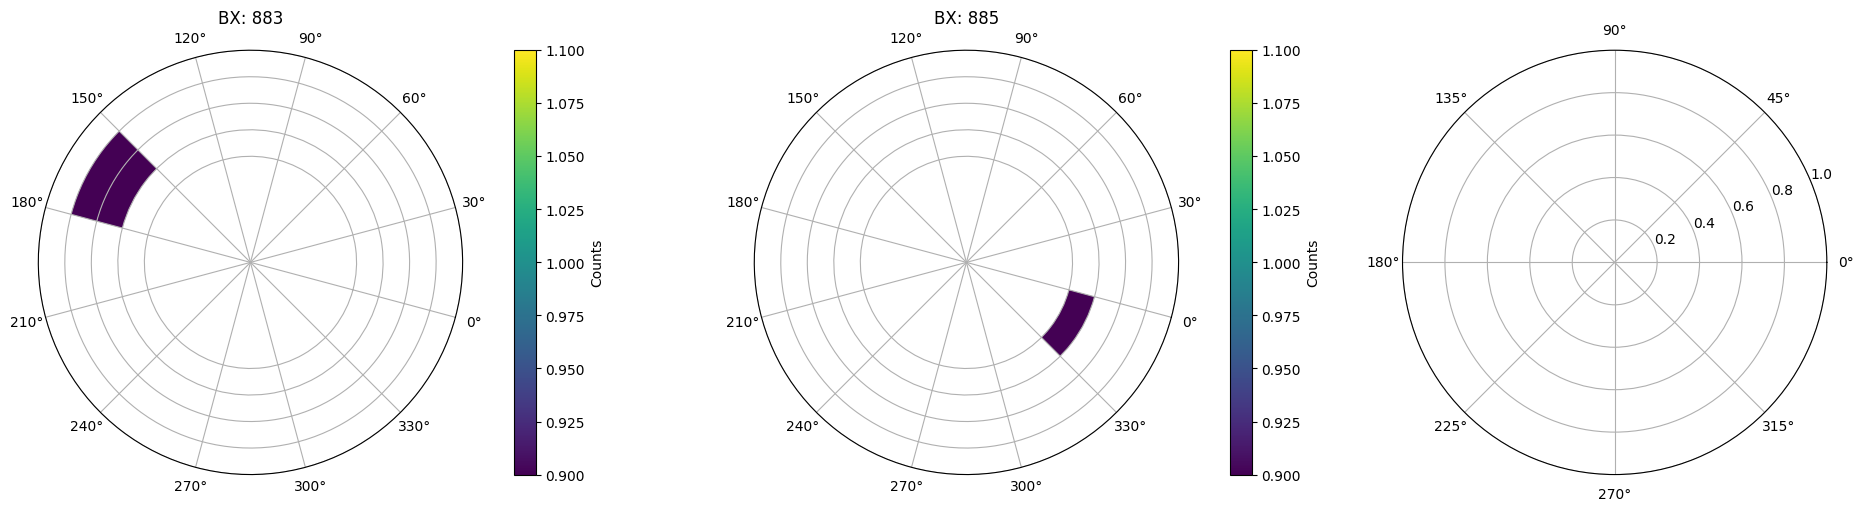

In [4]:
df_grouped = df.groupby("sequenceIndex")
index = 102

dfs = df_grouped.get_group(index)
dfs_grouped = dfs.groupby("L1BMTFStub_wheel")

wheel = 1
dfsw = dfs_grouped.get_group(wheel)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), subplot_kw={"projection": "polar"}, layout="constrained")

for ii, (bx, dfswb) in enumerate(dfsw.groupby("bunchCrossing")):
    axs[ii].set_title(f"BX: {bx}")
    axs[ii].set_thetagrids(range(0, 360, 30))
    axs[ii].set_theta_zero_location("E", -15)
    axs[ii].set_rlim(0, 2)
    axs[ii].set_yticklabels([])
    axs[ii].set_rgrids((0, 1, 1.25, 1.5, 1.75, 2))

    station_counts = {}
    for sector, station in zip(dfswb["L1BMTFStub_sector"].values, dfswb["L1BMTFStub_station"].values):
        sector = sector.item()
        station = station.item()

        if (sector, station) in station_counts:
            station_counts[(sector, station)] += 1

        else:
            station_counts[(sector, station)] = 1

    cmap_fill = cm.viridis
    norm_fill = Normalize(vmin=min(station_counts.values()), vmax=max(station_counts.values()))

    for key in station_counts:
        sector, station = key
        counts = station_counts[key]

        axs[ii].bar(
            x=sector * np.pi/6 + np.pi/12, 
            bottom=1.0 + (station - 1) * 0.25, 
            height=0.25,
            width=np.pi/6, 
            color=cmap_fill(norm_fill(counts))
        )

    sm = cm.ScalarMappable(cmap=cmap_fill, norm=norm_fill)
    sm.set_array([])
    plt.colorbar(sm, ax=axs[ii], orientation="vertical", label="Counts");

In [5]:
def getSameBxTargetCollections(bxs):
    target_pairs = [
        [(bx, station) for station in range(1, 4)] for bx in bxs
    ]

    target_pairs += [
        [(bx, station) for station in range(2, 5)] for bx in bxs
    ]

    return target_pairs

def getMultiBxTargetCollections(bxs):
    target_pairs = [
        [(bx, station) for bx, station in zip(bxs, range(1, 4))]
    ]

    target_pairs += [
        [(bx, station) for bx, station in zip(bxs, range(2, 5))]
    ]

    return target_pairs

In [6]:
same_bx_selection = {}
multi_bx_selection = {}

for idx_seq, df_seq in tqdm(df.groupby("sequenceIndex")):
    pairs = [
        tuple(el.item() for el in key) 
        for key in df_seq.groupby(["bunchCrossing", "L1BMTFStub_station"]).indices
    ]
    
    same_bx_collections = getSameBxTargetCollections(df_seq["bunchCrossing"].unique().tolist())

    for tps in same_bx_collections:
        if np.all([target_pair in pairs for target_pair in tps]):
            """
            Here we keep only the entries of the sequence sub-dataframe that 
            correspond to the identified (bx, station) pairs.
            This allows us then to groupby wheel and keep only the wheels that are
            at most distant 1 to one another.
            """
            mi = pd.MultiIndex.from_tuples(tps, names=["bunchCrossing", "L1BMTFStub_station"])
            df_temp = df_seq[
                df_seq.set_index(["bunchCrossing", "L1BMTFStub_station"]).index.isin(mi)
            ]

            if df_temp["L1BMTFStub_wheel"].max() - df_temp["L1BMTFStub_wheel"].min() > 1:
                if len(df_temp) <= 3:
                    continue

                else:
                    if df_temp[df_temp["L1BMTFStub_wheel"] < df_temp["L1BMTFStub_wheel"].max()]["bunchCrossing"].nunique() < 3:
                        if df_temp[df_temp["L1BMTFStub_wheel"] > df_temp["L1BMTFStub_wheel"].min()]["bunchCrossing"].nunique() < 3:
                            continue

                        else:
                            df_temp = df_temp[df_temp["L1BMTFStub_wheel"] > df_temp["L1BMTFStub_wheel"].min()]
                            same_bx_selection[idx_seq] = df_temp

                    else:
                        df_temp = df_temp[df_temp["L1BMTFStub_wheel"] < df_temp["L1BMTFStub_wheel"].max()]
                        same_bx_selection[idx_seq] = df_temp

            else:
                same_bx_selection[idx_seq] = df_temp

    multi_bx_collections = getMultiBxTargetCollections(df_seq["bunchCrossing"].unique().tolist())

    for tps in multi_bx_collections:
        if np.all([target_pair in pairs for target_pair in tps]):
            """
            Here we keep only the entries of the sequence sub-dataframe that 
            correspond to the identified (bx, station) pairs.
            This allows us then to groupby wheel and keep only the wheels that are
            at most distant 1 to one another.
            """
            mi = pd.MultiIndex.from_tuples(tps, names=["bunchCrossing", "L1BMTFStub_station"])
            df_temp = df_seq[
                df_seq.set_index(["bunchCrossing", "L1BMTFStub_station"]).index.isin(mi)
            ]

            if df_temp["L1BMTFStub_wheel"].max() - df_temp["L1BMTFStub_wheel"].min() > 1:
                if len(df_temp) <= 3:
                    continue

                else:
                    if df_temp[df_temp["L1BMTFStub_wheel"] < df_temp["L1BMTFStub_wheel"].max()]["bunchCrossing"].nunique() < 3:
                        if df_temp[df_temp["L1BMTFStub_wheel"] > df_temp["L1BMTFStub_wheel"].min()]["bunchCrossing"].nunique() < 3:
                            continue

                        else:
                            df_temp = df_temp[df_temp["L1BMTFStub_wheel"] > df_temp["L1BMTFStub_wheel"].min()]
                            multi_bx_selection[idx_seq] = df_temp

                    else:
                        df_temp = df_temp[df_temp["L1BMTFStub_wheel"] < df_temp["L1BMTFStub_wheel"].max()]
                        multi_bx_selection[idx_seq] = df_temp

            else:
                multi_bx_selection[idx_seq] = df_temp

  0%|          | 0/52973 [00:00<?, ?it/s]

In [7]:
print(len(same_bx_selection))
print(len(multi_bx_selection))

9569
1466


In [8]:
same_bx_selection.keys()

dict_keys([6, 8, 15, 18, 21, 22, 23, 26, 34, 45, 52, 54, 55, 60, 61, 82, 97, 116, 127, 128, 134, 152, 153, 164, 167, 179, 188, 199, 207, 219, 221, 228, 229, 240, 243, 245, 250, 251, 252, 256, 257, 262, 272, 273, 274, 275, 283, 284, 287, 292, 294, 302, 308, 312, 313, 316, 321, 324, 325, 333, 338, 355, 361, 367, 373, 380, 381, 385, 390, 395, 417, 424, 451, 452, 453, 457, 461, 462, 463, 466, 470, 484, 499, 503, 517, 530, 532, 541, 543, 544, 549, 552, 553, 563, 574, 587, 598, 600, 609, 611, 614, 615, 619, 622, 623, 625, 636, 637, 638, 652, 654, 666, 669, 672, 673, 681, 687, 695, 706, 716, 724, 725, 726, 730, 735, 738, 745, 751, 757, 765, 771, 773, 774, 776, 799, 801, 817, 831, 834, 846, 850, 851, 853, 856, 863, 865, 876, 881, 885, 886, 887, 898, 903, 905, 906, 909, 934, 955, 960, 961, 963, 969, 970, 973, 974, 975, 981, 982, 983, 998, 999, 1000, 1002, 1006, 1010, 1018, 1019, 1020, 1030, 1036, 1039, 1041, 1042, 1050, 1056, 1064, 1067, 1073, 1074, 1088, 1102, 1124, 1139, 1140, 1149, 1157, 115

In [9]:
same_bx_selection[128]

nL1BMTFStub  L1BMTFStub_hwQual  L1BMTFStub_hwPhi  \
entry subentry                                                     
384   0                   3                  4               985   
      1                   3                  3              -765   
      2                   3                  2              -575   

                L1BMTFStub_hwPhiB  L1BMTFStub_hwEta  L1BMTFStub_hwQEta  \
entry subentry                                                           
384   0                       291                16                  0   
      1                       225                 8                  8   
      2                       337                 0                  0   

                L1BMTFStub_wheel  L1BMTFStub_sector  L1BMTFStub_station  \
entry subentry                                                            
384   0                        1                  9                   1   
      1                        1                 10                   2   
      2                        1                 10                   3   

                orbitNumber  bunchCrossing  sequenceIndex  
entry subentry                                             
384   0           261882434           3283            128  
      1           261882434           3283            128  
      2           261882434           3283            128

In [10]:
multi_bx_selection.keys()

dict_keys([7, 47, 49, 60, 92, 134, 182, 211, 214, 251, 385, 417, 465, 470, 482, 504, 560, 577, 622, 652, 665, 686, 794, 817, 925, 963, 975, 983, 999, 1000, 1039, 1056, 1073, 1074, 1092, 1102, 1124, 1138, 1163, 1168, 1210, 1232, 1234, 1249, 1305, 1312, 1325, 1326, 1445, 1452, 1541, 1542, 1589, 1681, 1720, 1729, 1853, 1866, 1908, 1954, 2074, 2181, 2200, 2204, 2207, 2211, 2218, 2224, 2266, 2285, 2289, 2316, 2383, 2426, 2484, 2631, 2687, 2700, 2724, 2751, 2760, 2768, 2889, 2924, 2995, 3061, 3129, 3138, 3146, 3303, 3334, 3380, 3384, 3445, 3458, 3462, 3508, 3591, 3600, 3627, 3698, 3702, 3747, 3762, 3773, 3821, 3830, 3914, 3918, 3920, 3930, 3948, 3964, 3971, 4009, 4033, 4044, 4059, 4060, 4096, 4118, 4138, 4154, 4165, 4228, 4244, 4315, 4354, 4364, 4392, 4457, 4540, 4559, 4569, 4612, 4658, 4719, 4743, 4783, 4791, 4806, 4841, 4859, 4949, 5059, 5069, 5090, 5250, 5391, 5399, 5441, 5462, 5481, 5487, 5489, 5507, 5558, 5568, 5621, 5629, 5682, 5725, 5747, 5809, 5815, 5909, 5932, 5970, 6015, 6049, 6054

In [ ]:
multi_bx_selection[665] # INSPECT HERE

nL1BMTFStub  L1BMTFStub_hwQual  L1BMTFStub_hwPhi  \
entry subentry                                                     
1995  0                   1                  3              -480   
1996  0                   1                  2              -336   
1997  0                   3                  5              -374   
      1                   3                  5              -374   

                L1BMTFStub_hwPhiB  L1BMTFStub_hwEta  L1BMTFStub_hwQEta  \
entry subentry                                                           
1995  0                      -141                 0                  0   
1996  0                        68                 0                  0   
1997  0                      -110                 0                  0   
      1                      -110                 0                  0   

                L1BMTFStub_wheel  L1BMTFStub_sector  L1BMTFStub_station  \
entry subentry                                                            
1995  0                        1                  3                   2   
1996  0                        1                  3                   3   
1997  0                        2                  3                   4   
      1                        2                  3                   4   

                orbitNumber  bunchCrossing  sequenceIndex  
entry subentry                                             
1995  0           261885104           1695            665  
1996  0           261885104           1696            665  
1997  0           261885104           1697            665  
      1           261885104           1697            665

In [14]:
multi_bx_selection[794]

,,nL1BMTFStub,L1BMTFStub_hwQual,L1BMTFStub_hwPhi,L1BMTFStub_hwPhiB,L1BMTFStub_hwEta,L1BMTFStub_hwQEta,L1BMTFStub_wheel,L1BMTFStub_sector,L1BMTFStub_station,orbitNumber,bunchCrossing,sequenceIndex
entry,subentry,,,,,,,,,,,,
2382,0,1,4,-228,-280,0,0,-1,0,1,261885854,1342,794
2383,0,1,2,-514,-14,0,0,-1,0,2,261885854,1343,794
2384,1,2,3,-580,73,64,4,-2,0,3,261885854,1344,794


In [ ]:
df[df.index.isin()]

nL1BMTFStub  L1BMTFStub_hwQual  L1BMTFStub_hwPhi  \
entry subentry                                                     
1410  1                   3                  6               735   
      2                   3                  3               495   
1411  0                   5                  6               475   

                L1BMTFStub_hwPhiB  L1BMTFStub_hwEta  L1BMTFStub_hwQEta  \
entry subentry                                                           
1410  1                        44                 0                  0   
      2                      -399                 0                  0   
1411  0                      -129                32                 32   

                L1BMTFStub_wheel  L1BMTFStub_sector  L1BMTFStub_station  \
entry subentry                                                            
1410  1                        0                  9                   1   
      2                        0                  9                   2   
1411  0                        0                  8                   2   

                orbitNumber  bunchCrossing  sequenceIndex  
entry subentry                                             
1410  1           261884114           3286            470  
      2           261884114           3286            470  
1411  0           261884114           3287            470

In [29]:
df[df.index.get_level_values("entry").isin(list(range(1992, 2000)))]

nL1BMTFStub  L1BMTFStub_hwQual  L1BMTFStub_hwPhi  \
entry subentry                                                     
1992  0                   1                  4                -4   
1993  0                   2                  6               317   
      1                   2                  5                -4   
1994  0                   1                  4                -2   
1995  0                   1                  3              -480   
1996  0                   1                  2              -336   
1997  0                   3                  5              -374   
      1                   3                  5              -374   
      2                   3                  3              -500   
1998  0                   1                  2              -386   
1999  0                   1                  4               360   

                L1BMTFStub_hwPhiB  L1BMTFStub_hwEta  L1BMTFStub_hwQEta  \
entry subentry                                                           
1992  0                       281                 0                  0   
1993  0                       128                 0                  0   
      1                       279                16                 16   
1994  0                       284                 0                  0   
1995  0                      -141                 0                  0   
1996  0                        68                 0                  0   
1997  0                      -110                 0                  0   
      1                      -110                 0                  0   
      2                       179                 0                  0   
1998  0                        49                 0                  0   
1999  0                      -480                 0                  0   

                L1BMTFStub_wheel  L1BMTFStub_sector  L1BMTFStub_station  \
entry subentry                                                            
1992  0                        0                  5                   1   
1993  0                        0                  5                   2   
      1                        0                  5                   1   
1994  0                        0                  5                   1   
1995  0                        1                  3                   2   
1996  0                        1                  3                   3   
1997  0                        2                  3                   4   
      1                        2                  3                   4   
      2                        1                  3                   2   
1998  0                        1                 10                   1   
1999  0                        1                  9                   1   

                orbitNumber  bunchCrossing  sequenceIndex  
entry subentry                                             
1992  0           261885104            140            664  
1993  0           261885104            141            664  
      1           261885104            141            664  
1994  0           261885104            142            664  
1995  0           261885104           1695            665  
1996  0           261885104           1696            665  
1997  0           261885104           1697            665  
      1           261885104           1697            665  
      2           261885104           1697            665  
1998  0           261885104           2036            666  
1999  0           261885104           2037            666